In [16]:
import matplotlib.pyplot as plt
import geopandas as gpd

In [17]:
ds = gpd.read_file("../data/raw/shapes/BR_UF_2025.shp")
estados_ne = ds[ds["NM_REGIAO"] == "Nordeste"]
estados_ne

,CD_UF,NM_UF,SIGLA_UF,CD_REGIAO,NM_REGIAO,SIGLA_RG,AREA_KM2,geometry
7,23,Ceará,CE,2,Nordeste,NE,148894.440,"POLYGON ((-39.08952 -7.83948, -39.08869 -7.838..."
9,24,Rio Grande do Norte,RN,2,Nordeste,NE,52809.600,"MULTIPOLYGON (((-37.26699 -6.75262, -37.26802 ..."
10,21,Maranhão,MA,2,Nordeste,NE,329651.463,"MULTIPOLYGON (((-45.86986 -10.07488, -45.87149..."
12,22,Piauí,PI,2,Nordeste,NE,251755.499,"POLYGON ((-44.8869 -10.90267, -44.88952 -10.90..."
15,27,Alagoas,AL,2,Nordeste,NE,27830.662,"MULTIPOLYGON (((-35.75903 -9.69384, -35.75888 ..."
17,28,Sergipe,SE,2,Nordeste,NE,21938.188,"MULTIPOLYGON (((-36.91874 -10.84588, -36.91853..."
19,25,Paraíba,PB,2,Nordeste,NE,56467.243,"MULTIPOLYGON (((-34.79785 -7.36312, -34.79795 ..."
20,26,Pernambuco,PE,2,Nordeste,NE,98064.415,"MULTIPOLYGON (((-35.02442 -8.61222, -35.02443 ..."
24,29,Bahia,BA,2,Nordeste,NE,564763.876,"MULTIPOLYGON (((-39.20707 -17.96668, -39.20712..."


In [18]:
from pathlib import Path

# Os dados ERA5 usam coordenadas geográficas (EPSG:4326).
agrupamentos = {
    "BA_SE": ["BA", "SE"],
    "PB_RN": ["PB", "RN"],
    "AL_PE": ["AL", "PE"],
}
siglas_agrupadas = {sigla for grupo in agrupamentos.values() for sigla in grupo}

regioes = [
    {
        "SIGLA_UF": nome_grupo,
        "geometry": estados_ne.loc[
            estados_ne["SIGLA_UF"].isin(siglas), "geometry"
        ].union_all(),
    }
    for nome_grupo, siglas in agrupamentos.items()
]
regioes.extend(
    {
        "SIGLA_UF": estado["SIGLA_UF"],
        "geometry": estado.geometry,
    }
    for _, estado in estados_ne.iterrows()
    if estado["SIGLA_UF"] not in siglas_agrupadas
)

estados_ne_era5 = gpd.GeoDataFrame(regioes, crs=estados_ne.crs).to_crs("EPSG:4326")

pasta_shapes = Path("../data/shapes-estados")
pasta_shapes.mkdir(parents=True, exist_ok=True)

for caminho_shp in pasta_shapes.glob("*.shp"):
    for extensao in (".cpg", ".dbf", ".prj", ".shp", ".shx"):
        caminho_shp.with_suffix(extensao).unlink(missing_ok=True)

for sigla_uf, estado in estados_ne_era5.groupby("SIGLA_UF"):
    estado[["SIGLA_UF", "geometry"]].to_file(pasta_shapes / f"{sigla_uf}.shp")

sorted(estados_ne_era5["SIGLA_UF"])

['AL_PE', 'BA_SE', 'CE', 'MA', 'PB_RN', 'PI']

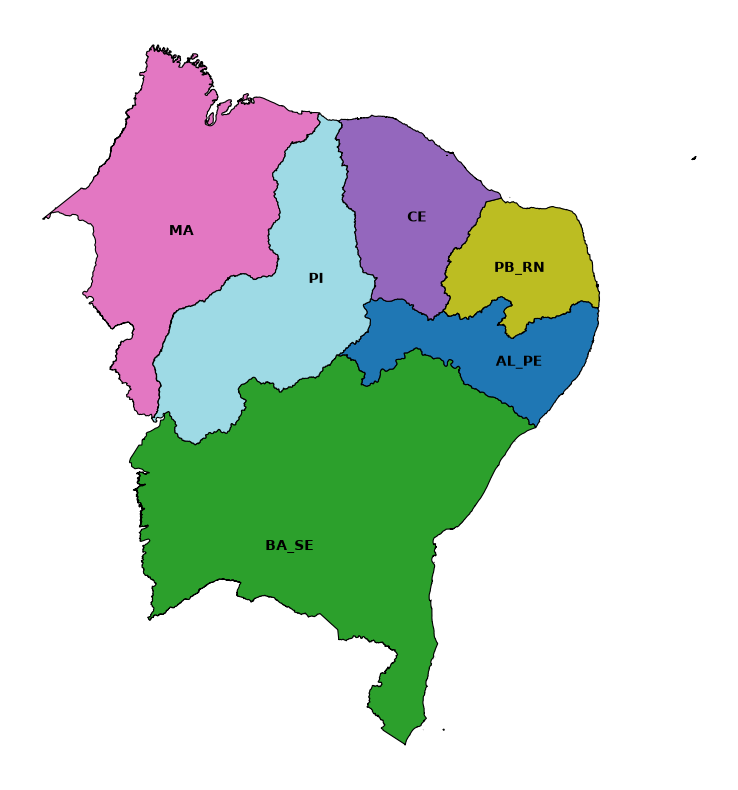

In [19]:
fig, ax = plt.subplots(figsize=(10, 10))

estados_ne_era5.plot(
    ax=ax,
    column="SIGLA_UF",
    categorical=True,
    cmap="tab20",
    edgecolor="black",
    linewidth=0.8,
)

for _, estado in estados_ne_era5.iterrows():
    ponto = estado.geometry.representative_point()
    ax.annotate(
        estado["SIGLA_UF"],
        xy=(ponto.x, ponto.y),
        ha="center",
        va="center",
        fontweight="bold",
    )

ax.set_axis_off()
plt.show()

In [ ]:
# estados_ne.to_file("../data/processed/shapes/estados_ne.shp")